<a href="https://colab.research.google.com/github/akshita-1218/CelebalTechnologiesDS_Assignment/blob/main/Week6_AkshitaSharma.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Autoencoder for Image Denoising using MNIST

## Introduction

Image denoising is the process of removing unwanted noise from images while preserving important features. In this project, a Convolutional Denoising Autoencoder is built using the MNIST handwritten digit dataset. Gaussian noise is added to the original images, and the model is trained to reconstruct the clean images from the noisy inputs.

In [1]:
import zipfile

zip_path = "/content/archive (3).zip"
extract_path = "/content/mnist_data"

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [2]:
import os

print(os.listdir("/content/mnist_data"))

['mnist_png']


In [3]:
import os

print(os.listdir("/content/mnist_data/mnist_png"))

['testing', 'training']


In [4]:
print(os.listdir("/content/mnist_data/mnist_png/training"))

['6', '7', '2', '1', '5', '8', '4', '0', '9', '3']


In [5]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf

from tensorflow.keras.preprocessing.image import load_img, img_to_array
import os

In [6]:
def load_images(folder_path):

    images = []

    for digit in sorted(os.listdir(folder_path)):
        digit_folder = os.path.join(folder_path, digit)

        if os.path.isdir(digit_folder):

            for image_name in os.listdir(digit_folder):

                image_path = os.path.join(digit_folder, image_name)

                image = load_img(
                    image_path,
                    color_mode='grayscale',
                    target_size=(28,28)
                )

                image = img_to_array(image)

                images.append(image)

    images = np.array(images)

    return images

In [7]:
train_path = "/content/mnist_data/mnist_png/training"
test_path = "/content/mnist_data/mnist_png/testing"

x_train = load_images(train_path)
x_test = load_images(test_path)

print("Training Shape :", x_train.shape)
print("Testing Shape :", x_test.shape)

Training Shape : (60000, 28, 28, 1)
Testing Shape : (10000, 28, 28, 1)


In [8]:
x_train = x_train.astype("float32") / 255.0
x_test = x_test.astype("float32") / 255.0

print("Minimum pixel value:", x_train.min())
print("Maximum pixel value:", x_train.max())

Minimum pixel value: 0.0
Maximum pixel value: 1.0


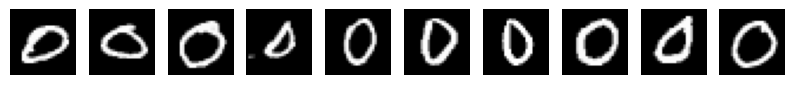

In [9]:
plt.figure(figsize=(10,2))

for i in range(10):
    plt.subplot(1,10,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.axis("off")

plt.show()

In [11]:
noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_test_noisy = x_test + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_test.shape
)
x_train_noisy = np.clip(x_train_noisy, 0., 1.)
x_test_noisy = np.clip(x_test_noisy, 0., 1.)

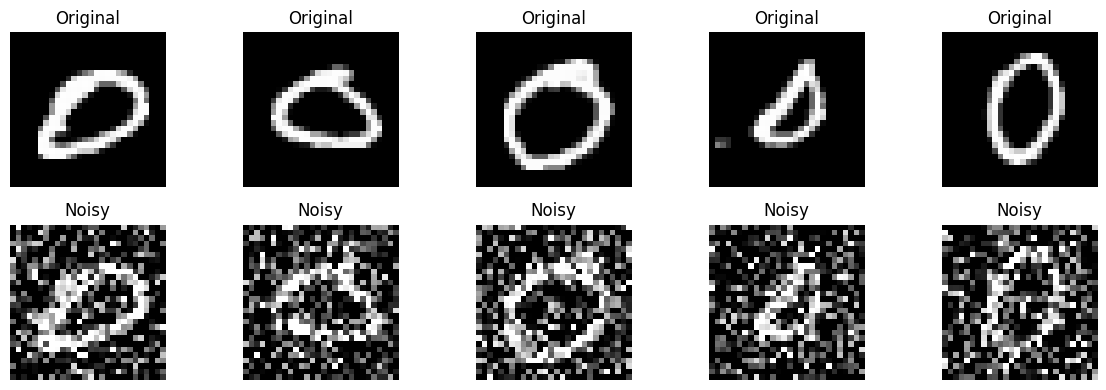

In [12]:
plt.figure(figsize=(12,4))

for i in range(5):

    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(2,5,i+6)
    plt.imshow(x_train_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

In [13]:
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model

input_img = Input(shape=(28, 28, 1))

x = Conv2D(32, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

x = Conv2D(16, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation='relu', padding='same')(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

autoencoder = Model(input_img, decoded)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 16)     │         4,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 16)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 16)       │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 12,193 (47.63 KB)

 Trainable params: 12,193 (47.63 KB)

 Non-trainable params: 0 (0.00 B)

In [14]:
autoencoder.compile(
    optimizer='adam',
    loss='binary_crossentropy'
)

In [15]:
history = autoencoder.fit(
    x_train_noisy,
    x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_test_noisy, x_test)
)

Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 103s 215ms/step - loss: 0.1795 - val_loss: 0.1239
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 143s 216ms/step - loss: 0.1196 - val_loss: 0.1141
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 139s 210ms/step - loss: 0.1132 - val_loss: 0.1099
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 215ms/step - loss: 0.1099 - val_loss: 0.1076
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 214ms/step - loss: 0.1079 - val_loss: 0.1061
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - loss: 0.1064 - val_loss: 0.1047
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.1051 - val_loss: 0.1034
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 101s 216ms/step - loss: 0.1040 - val_loss: 0.1024
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 100s 212ms/step - loss: 0.1032 - val_loss: 0.1023
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 99s 211ms/step - loss: 0.1025 - val_loss: 0.1011


In [16]:
decoded_imgs = autoencoder.predict(x_test_noisy)

313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step


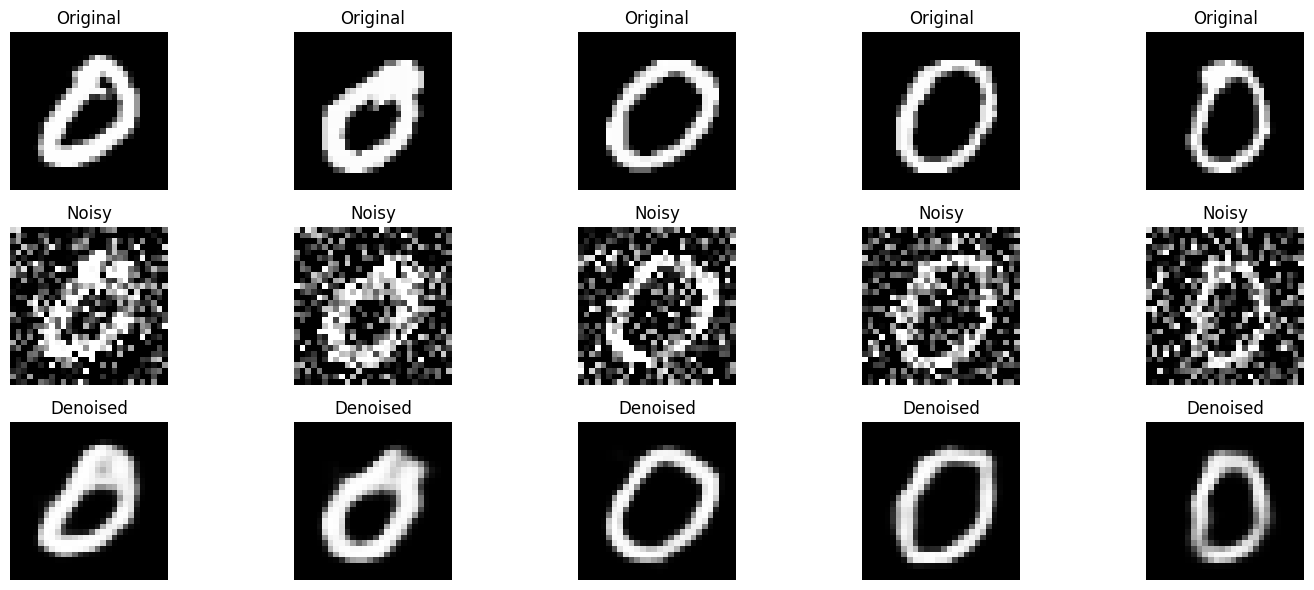

In [17]:
plt.figure(figsize=(15,6))

n = 5

for i in range(n):

    # Original Image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_test[i].reshape(28,28), cmap='gray')
    plt.title("Original")
    plt.axis("off")

    # Noisy Image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(x_test_noisy[i].reshape(28,28), cmap='gray')
    plt.title("Noisy")
    plt.axis("off")

    # Denoised Image
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28,28), cmap='gray')
    plt.title("Denoised")
    plt.axis("off")

plt.tight_layout()
plt.show()

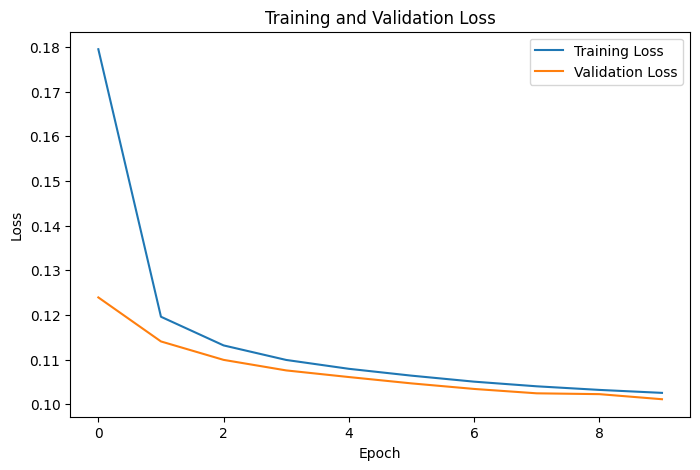

In [18]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")
plt.legend()

plt.show()

## Conclusion

In this project, a Convolutional Denoising Autoencoder was developed using the MNIST dataset. Gaussian noise was added to the images, and the model was trained to reconstruct the original clean images. The results demonstrate that the autoencoder successfully reduces noise while preserving the handwritten digit structure, showing the effectiveness of autoencoders for image denoising tasks.